# AgroScan — Adaptation graduelle : PlantVillage → PlantWild → PlantDoc

## Prérequis : téléchargement de PlantWild

```bash
# Option 1 : via kagglehub (automatique)
pip install kagglehub
# Les credentials Kaggle doivent être configurés (~/.kaggle/kaggle.json)

# Option 2 : téléchargement direct sur https://www.kaggle.com/datasets/thuanai1/plantwild
# Extraire dans data/plantwild/ avec la structure train/ val/ test/
```

## 1. Lancement

```bash
./scripts/tf_gpu_env.sh uv run jupyter lab
```

In [1]:
# %pip install -r ../requirements.txt kagglehub

In [1]:
import shutil
import subprocess
from pathlib import Path
import json
import time
from difflib import SequenceMatcher

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import tensorflow as tf
import tensorflow_datasets as tfds

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

I0000 00:00:1779722796.115991   18246 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779722796.959739   18246 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779722797.446491   18246 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Configuration

In [2]:

import os

# Détection robuste de la racine projet
_env_root = Path(os.environ['AGROSCAN_ROOT']) if 'AGROSCAN_ROOT' in os.environ else None
_colab_root = Path('/content') if Path('/content').exists() and Path('/opt/google').exists() else None
_cwd = Path('.').resolve()
try:
    _starting_dir = Path(get_ipython().starting_dir).resolve()
except (NameError, AttributeError):
    _starting_dir = _cwd

_candidates = list(dict.fromkeys(filter(None, [
    _env_root, _cwd, _starting_dir, *_cwd.parents, *_starting_dir.parents
])))
ROOT = next(
    (p for p in _candidates if (p / 'requirements.txt').exists()),
    _env_root or _colab_root or _cwd,
)

DATA_DIR   = ROOT / 'data'
MODEL_DIR  = ROOT / 'models'
REPORT_DIR = ROOT / 'reports'

for d in [MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
AUTOTUNE   = tf.data.AUTOTUNE

# Phase 1 : PlantVillage (backbone gelé)
EPOCHS_P1 = 10
LR_P1     = 1e-3

# Phase 2 : PlantWild bridge (25% backbone dégelé)
EPOCHS_P2      = 20
LR_P2          = 1e-4
UNFREEZE_RATIO = 0.75   # garder 75 % gelé → 25 % dégelé

# Phase 3 : PlantDoc fine-tuning (même dégel, LR plus faible)
EPOCHS_P3 = 40
LR_P3     = 5e-5

tf.keras.utils.set_random_seed(SEED)
print('Racine projet:', ROOT)
print('Models      :', MODEL_DIR)


Racine projet: /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan
Models      : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models


## 3. Chargement de PlantVillage

In [3]:
(pv_train_raw, pv_val_raw, pv_test_raw), info = tfds.load(
    'plant_village',
    split=['train[:70%]', 'train[70%:85%]', 'train[85%:]'],
    as_supervised=True,
    with_info=True,
    data_dir=str(DATA_DIR / 'tfds'),
)

class_names      = info.features['label'].names
num_classes      = len(class_names)
pv_label_to_idx  = {name: idx for idx, name in enumerate(class_names)}

print(f'PlantVillage : {num_classes} classes')
print(f'Ex. : {class_names[:5]}')

PlantVillage : 38 classes
Ex. : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


W0000 00:00:1779722805.054363   18246 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 4. Configuration PlantDoc

In [4]:
PLANTDOC_DIR       = DATA_DIR / 'plantdoc'
PLANTDOC_TRAIN_DIR = PLANTDOC_DIR / 'train'
PLANTDOC_TEST_DIR  = PLANTDOC_DIR / 'test'

plantdoc_to_plantvillage = {
    'Apple Scab Leaf':                       'Apple___Apple_scab',
    'Apple leaf':                            'Apple___healthy',
    'Apple rust leaf':                       'Apple___Cedar_apple_rust',
    'Bell_pepper leaf':                      'Pepper,_bell___healthy',
    'Bell_pepper leaf spot':                 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf':                        'Blueberry___healthy',
    'Cherry leaf':                           'Cherry___healthy',
    'Corn Gray leaf spot':                   'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight':                      'Corn___Northern_Leaf_Blight',
    'Corn rust leaf':                        'Corn___Common_rust',
    'Peach leaf':                            'Peach___healthy',
    'Potato leaf early blight':              'Potato___Early_blight',
    'Potato leaf late blight':               'Potato___Late_blight',
    'Raspberry leaf':                        'Raspberry___healthy',
    'Soyabean leaf':                         'Soybean___healthy',
    'Squash Powdery mildew leaf':            'Squash___Powdery_mildew',
    'Strawberry leaf':                       'Strawberry___healthy',
    'Tomato Early blight leaf':              'Tomato___Early_blight',
    'Tomato Septoria leaf spot':             'Tomato___Septoria_leaf_spot',
    'Tomato leaf':                           'Tomato___healthy',
    'Tomato leaf bacterial spot':            'Tomato___Bacterial_spot',
    'Tomato leaf late blight':               'Tomato___Late_blight',
    'Tomato leaf mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus':              'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf':                      'Tomato___Leaf_Mold',
    'Tomato two spotted spider mites leaf':  'Tomato___Spider_mites Two-spotted_spider_mite',
    'grape leaf':                            'Grape___healthy',
    'grape leaf black rot':                  'Grape___Black_rot',
}

if not PLANTDOC_TEST_DIR.exists():
    print('Téléchargement de PlantDoc...')
    PLANTDOC_DIR.mkdir(parents=True, exist_ok=True)
    tmp = DATA_DIR / '_pd_clone'
    subprocess.run(
        ['git', 'clone', '--depth', '1',
         'https://github.com/pratikkayal/PlantDoc-Dataset.git', str(tmp)],
        check=True,
    )
    for split in ('train', 'test'):
        src, dst = tmp / split, PLANTDOC_DIR / split
        if src.exists() and not dst.exists():
            shutil.copytree(src, dst)
    shutil.rmtree(tmp)

plantdoc_classes = sorted(p.name for p in PLANTDOC_TEST_DIR.iterdir() if p.is_dir())
valid_pd_mapping = {
    k: v for k, v in plantdoc_to_plantvillage.items()
    if k in plantdoc_classes and v in class_names
}
print(f'PlantDoc test : {len(plantdoc_classes)} classes | {len(valid_pd_mapping)} évaluables')

PlantDoc test : 27 classes | 27 évaluables


## 5. Chargement et mapping de PlantWild

PlantWild utilise des noms de classes en minuscules avec espaces (`apple scab`) tandis que PlantVillage utilise `Plant___Disease`. Un mapping est fourni pour les classes communes. Les classes sans équivalent PlantVillage (banana, basil, bean, broccoli, etc.) sont exclues — le modèle ne peut pas les classifier avec nos 38 labels.

In [5]:
PLANTWILD_DIR = DATA_DIR / 'plantwild'

if not PLANTWILD_DIR.exists():
    print('PlantWild non trouvé. Tentative de téléchargement via kagglehub...')
    try:
        import kagglehub
        path = kagglehub.dataset_download('thuanai1/plantwild')
        PLANTWILD_DIR = Path(path)
        print('Téléchargé dans :', PLANTWILD_DIR)
    except Exception as e:
        raise FileNotFoundError(
            f"PlantWild non trouvé et téléchargement automatique échoué ({e}).\n"
            "Télécharger manuellement sur https://www.kaggle.com/datasets/thuanai1/plantwild\n"
            "et extraire dans data/plantwild/ (attendu : data/plantwild/train/, data/plantwild/test/)"
        ) from e

# Chercher le dossier train (peut être à la racine ou dans un sous-dossier)
for candidate in [PLANTWILD_DIR, PLANTWILD_DIR / 'plantwild', *list(PLANTWILD_DIR.iterdir())]:
    if (candidate / 'train').exists():
        PLANTWILD_TRAIN_DIR = candidate / 'train'
        PLANTWILD_VAL_DIR   = candidate / 'val'
        break
else:
    raise FileNotFoundError(f'Structure train/ introuvable dans {PLANTWILD_DIR}')

print('PlantWild train :', PLANTWILD_TRAIN_DIR)

PlantWild train : /home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/data/plantwild/train


In [6]:
# Mapping PlantWild (lowercase) → PlantVillage (Plant___Disease)
# Les classes sans correspondance (banana, basil, bean, broccoli, cabbage, carrot,
# cauliflower, celery, apple mosaic virus, blueberry rust, cherry leaf spot...)
# sont absentes de PlantVillage et seront ignorées.
plantwild_to_plantvillage = {
    # Apple
    'apple scab':                       'Apple___Apple_scab',
    'apple black rot':                  'Apple___Black_rot',
    'apple rust':                       'Apple___Cedar_apple_rust',
    'apple leaf':                       'Apple___healthy',
    # Blueberry
    'blueberry leaf':                   'Blueberry___healthy',
    # Cherry
    'cherry leaf':                      'Cherry___healthy',
    'cherry powdery mildew':            'Cherry___Powdery_mildew',
    # Corn
    'corn gray leaf spot':              'Corn___Cercospora_leaf_spot Gray_leaf_spot',
    'corn leaf blight':                 'Corn___Northern_Leaf_Blight',
    'corn rust':                        'Corn___Common_rust',
    'corn leaf':                        'Corn___healthy',
    # Grape
    'grape black rot':                  'Grape___Black_rot',
    'grape esca':                       'Grape___Esca_(Black_Measles)',
    'grape leaf blight':                'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
    'grape leaf':                       'Grape___healthy',
    # Orange
    'orange citrus greening':           'Orange___Haunglongbing_(Citrus_greening)',
    'orange haunglongbing':             'Orange___Haunglongbing_(Citrus_greening)',
    # Peach
    'peach bacterial spot':             'Peach___Bacterial_spot',
    'peach leaf':                       'Peach___healthy',
    # Pepper
    'bell pepper leaf spot':            'Pepper,_bell___Bacterial_spot',
    'bell pepper leaf':                 'Pepper,_bell___healthy',
    # Potato
    'potato early blight':              'Potato___Early_blight',
    'potato late blight':               'Potato___Late_blight',
    'potato leaf':                      'Potato___healthy',
    # Raspberry
    'raspberry leaf':                   'Raspberry___healthy',
    # Soybean
    'soybean leaf':                     'Soybean___healthy',
    # Squash
    'squash powdery mildew':            'Squash___Powdery_mildew',
    # Strawberry
    'strawberry leaf scorch':           'Strawberry___Leaf_scorch',
    'strawberry leaf':                  'Strawberry___healthy',
    # Tomato
    'tomato bacterial spot':            'Tomato___Bacterial_spot',
    'tomato early blight':              'Tomato___Early_blight',
    'tomato late blight':               'Tomato___Late_blight',
    'tomato leaf mold':                 'Tomato___Leaf_Mold',
    'tomato septoria leaf spot':        'Tomato___Septoria_leaf_spot',
    'tomato spider mites':              'Tomato___Spider_mites Two-spotted_spider_mite',
    'tomato target spot':               'Tomato___Target_Spot',
    'tomato yellow leaf curl virus':    'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'tomato mosaic virus':              'Tomato___Tomato_mosaic_virus',
    'tomato leaf':                      'Tomato___healthy',
}

print(f'Mapping fourni : {len(plantwild_to_plantvillage)} classes → PlantVillage')

Mapping fourni : 39 classes → PlantVillage


In [7]:
def fuzzy_match(query: str, candidates: list[str], threshold: float = 0.7) -> str | None:
    """Tente de trouver la meilleure correspondance floue pour une classe non mappée."""
    best, best_score = None, 0.0
    for c in candidates:
        score = SequenceMatcher(None, query, c).ratio()
        if score > best_score:
            best, best_score = c, score
    return best if best_score >= threshold else None


def load_plantwild_split(split_dir: Path) -> tuple[list[str], list[int]]:
    """Charge un split PlantWild et retourne (chemins, labels_PV)."""
    image_exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    paths, labels = [], []
    unmapped_classes = {}

    for cls_dir in sorted(split_dir.iterdir()):
        if not cls_dir.is_dir():
            continue
        cls_name = cls_dir.name.lower()

        pv_cls = plantwild_to_plantvillage.get(cls_name)
        if pv_cls is None:
            # Tentative de correspondance floue
            pv_cls = fuzzy_match(cls_name, list(plantwild_to_plantvillage.keys()))
            if pv_cls:
                pv_cls = plantwild_to_plantvillage[pv_cls]

        if pv_cls is None or pv_cls not in pv_label_to_idx:
            imgs = [f for f in cls_dir.iterdir() if f.is_file() and f.suffix.lower() in image_exts]
            unmapped_classes[cls_dir.name] = len(imgs)
            continue

        pv_idx = pv_label_to_idx[pv_cls]
        for p in cls_dir.iterdir():
            if p.is_file() and p.suffix.lower() in image_exts:
                paths.append(str(p))
                labels.append(pv_idx)

    return paths, labels, unmapped_classes


pw_train_paths, pw_train_labels, pw_unmapped_train = load_plantwild_split(PLANTWILD_TRAIN_DIR)

if PLANTWILD_VAL_DIR.exists():
    pw_val_paths, pw_val_labels, _ = load_plantwild_split(PLANTWILD_VAL_DIR)
else:
    # Si pas de split val, faire 80/20
    rng = np.random.default_rng(SEED)
    perm = rng.permutation(len(pw_train_paths))
    pw_train_paths = [pw_train_paths[i] for i in perm]
    pw_train_labels = [pw_train_labels[i] for i in perm]
    n_val = int(0.2 * len(pw_train_paths))
    pw_val_paths,   pw_val_labels   = pw_train_paths[:n_val],  pw_train_labels[:n_val]
    pw_train_paths, pw_train_labels = pw_train_paths[n_val:],  pw_train_labels[n_val:]

print(f'PlantWild train : {len(pw_train_paths):,} images | val : {len(pw_val_paths):,} images')
print(f'Classes couvertes : {len(set(pw_train_labels))} / {num_classes}')
print(f'\nClasses PlantWild ignorées (pas de correspondance PV) :')
for cls, n in sorted(pw_unmapped_train.items(), key=lambda x: -x[1]):
    print(f'  {cls} ({n} images)')

PlantWild train : 7,984 images | val : 1,119 images
Classes couvertes : 33 / 38

Classes PlantWild ignorées (pas de correspondance PV) :
  citrus canker (375 images)
  cabbage leaf (326 images)
  squash leaf (287 images)
  grape downy mildew (277 images)
  cucumber leaf (245 images)
  broccoli leaf (189 images)
  cucumber angular leaf spot (176 images)
  rice sheath blight (175 images)
  lettuce leaf (172 images)
  banana leaf (171 images)
  eggplant leaf (168 images)
  citrus greening disease (167 images)
  garlic leaf (161 images)
  banana panama disease (152 images)
  cauliflower leaf (137 images)
  coffee leaf rust (133 images)
  zucchini yellow mosaic virus (127 images)
  ginger leaf (125 images)
  bean rust (116 images)
  garlic rust (112 images)
  rice blast (105 images)
  cucumber bacterial wilt (101 images)
  grapevine leafroll disease (98 images)
  maple tar spot (98 images)
  cabbage alternaria leaf spot (91 images)
  lettuce downy mildew (84 images)
  bean halo blight (81 i

In [9]:
# Distribution PlantWild par classe PlantVillage
pw_counts = np.zeros(num_classes, dtype=int)
for lbl in pw_train_labels:
    pw_counts[lbl] += 1

print('Distribution PlantWild (top 20) :')
df_pw = pd.DataFrame({'classe': class_names, 'n': pw_counts}).query('n > 0')
df_pw.sort_values('n', ascending=False).head(20)

Distribution PlantWild (top 20) :


,classe,n
3,Apple___healthy,1175
5,Cherry___healthy,511
36,Tomato___Tomato_mosaic_virus,482
13,Grape___healthy,393
8,Corn___Common_rust,373
24,Soybean___healthy,352
4,Blueberry___healthy,280
17,Peach___healthy,276
6,Cherry___Powdery_mildew,247
29,Tomato___Early_blight,243


## 6. Augmentation et prétraitement

In [8]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical', seed=SEED),
    tf.keras.layers.RandomRotation(0.25, seed=SEED),
    tf.keras.layers.RandomZoom((-0.35, 0.1), seed=SEED),
    tf.keras.layers.RandomContrast(0.4, seed=SEED),
    tf.keras.layers.RandomBrightness(0.2, seed=SEED),
    tf.keras.layers.Lambda(
        lambda x: x + tf.random.normal(tf.shape(x), mean=0.0, stddev=10.0),
        name='gaussian_noise_10',
    ),
], name='data_augmentation_realistic')


def preprocess_pv(image, label, augment=False):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    if augment:
        image = data_augmentation(image, training=True)
    return image, label


def load_image(path, label, augment=False):
    raw = tf.io.read_file(path)
    img = tf.image.decode_image(raw, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if augment:
        img = data_augmentation(img, training=True)
    return img, label

## 7. Construction des datasets

In [9]:
# Phase 1 : PlantVillage 
p1_train_ds = (
    pv_train_raw
    .shuffle(4096, seed=SEED)
    .map(lambda x, y: preprocess_pv(x, y, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
p1_val_ds = (
    pv_val_raw
    .map(preprocess_pv, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Phase 2 : PlantWild
p2_train_ds = (
    tf.data.Dataset.from_tensor_slices((pw_train_paths, pw_train_labels))
    .shuffle(4096, seed=SEED)
    .map(lambda p, l: load_image(p, l, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
p2_val_ds = (
    tf.data.Dataset.from_tensor_slices((pw_val_paths, pw_val_labels))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Phase 3 : PlantDoc
ft_paths, ft_labels = [], []
for pd_cls, pv_cls in plantdoc_to_plantvillage.items():
    cls_dir = PLANTDOC_TRAIN_DIR / pd_cls
    if not cls_dir.exists() or pv_cls not in pv_label_to_idx:
        continue
    idx = pv_label_to_idx[pv_cls]
    for p in sorted(cls_dir.iterdir()):
        if p.is_file():
            ft_paths.append(str(p))
            ft_labels.append(idx)

rng = np.random.default_rng(SEED)
perm = rng.permutation(len(ft_paths))
ft_paths  = [ft_paths[i]  for i in perm]
ft_labels = [ft_labels[i] for i in perm]

n_val_ft = int(0.2 * len(ft_paths))
ft_val_paths,   ft_val_labels   = ft_paths[:n_val_ft],  ft_labels[:n_val_ft]
ft_train_paths, ft_train_labels = ft_paths[n_val_ft:],  ft_labels[n_val_ft:]

p3_train_ds = (
    tf.data.Dataset.from_tensor_slices((ft_train_paths, ft_train_labels))
    .shuffle(2048, seed=SEED)
    .map(lambda p, l: load_image(p, l, augment=True), num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
p3_val_ds = (
    tf.data.Dataset.from_tensor_slices((ft_val_paths, ft_val_labels))
    .map(load_image, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

# Dataset de test (évaluation finale)
pv_test_ds = (
    pv_test_raw
    .map(preprocess_pv, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f'Phase 1 (PV)      train : {sum(1 for _ in pv_train_raw):,}')
print(f'Phase 2 (Wild)    train : {len(pw_train_paths):,}')
print(f'Phase 3 (PDoc)    train : {len(ft_train_paths):,}')

Phase 1 (PV)      train : 38,012
Phase 2 (Wild)    train : 7,984
Phase 3 (PDoc)    train : 1,874


## 8. Modèle : MobileNetV3Small

In [10]:
base_model = tf.keras.applications.MobileNetV3Small(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet',
    include_preprocessing=True,
)
base_model.trainable = False

inputs  = tf.keras.Input(shape=IMG_SIZE + (3,))
x       = base_model(inputs, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dropout(0.25)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs, name='agroscan_mobilenetv3_plantwild')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

total_params = model.count_params()
print(f'Total params : {total_params:,}')

Total params : 961,046


## 9. Phase 1 — PlantVillage (backbone gelé)

Le modèle apprend à classifier 38 maladies végétales sur des images studio contrôlées. Le backbone reste gelé (features ImageNet), seule la tête de classification est entraînée.

Epoch 1/10


E0000 00:00:1779722828.770393   18509 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1185/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6067 - loss: 1.5305

E0000 00:00:1779722852.927076   18507 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6070 - loss: 1.5290

E0000 00:00:1779722858.329256   18507 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 35s 24ms/step - accuracy: 0.7517 - loss: 0.9408 - val_accuracy: 0.8806 - val_loss: 0.4512
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8777 - loss: 0.4328 - val_accuracy: 0.8869 - val_loss: 0.3717
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.8935 - loss: 0.3544 - val_accuracy: 0.9024 - val_loss: 0.3100
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9033 - loss: 0.3151 - val_accuracy: 0.9143 - val_loss: 0.2739
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9072 - loss: 0.2966 - val_accuracy: 0.9126 - val_loss: 0.2673
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9103 - loss: 0.2873 - val_accuracy: 0.9157 - val_loss: 0.2581
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9130 - loss: 0.2756 - val_accuracy: 0.9179 - val_loss: 0.2449
Epoch 8/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9144 - loss: 0.26

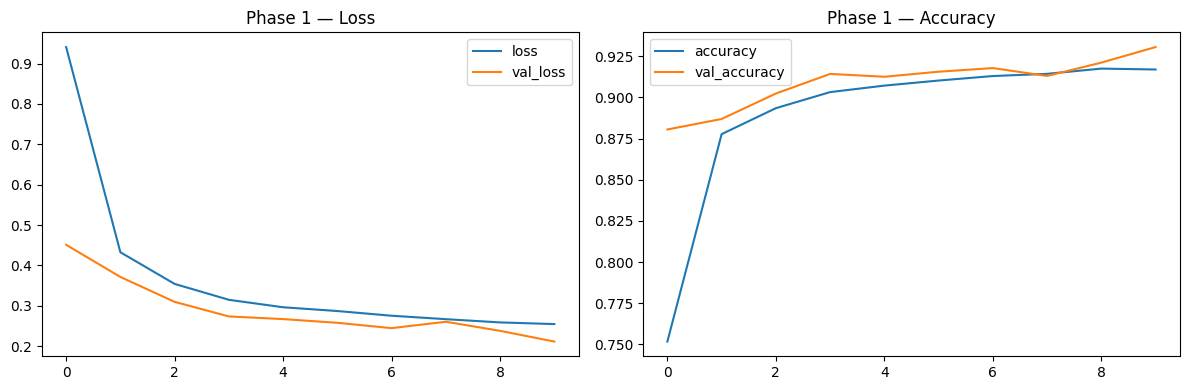

In [11]:
ckpt_p1 = str(MODEL_DIR / 'plantwild_phase1.keras')

callbacks_p1 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p1, monitor='val_accuracy', save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=2, restore_best_weights=True,
    ),
]

history_p1 = model.fit(
    p1_train_ds,
    validation_data=p1_val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
)

pd.DataFrame(history_p1.history).to_csv(REPORT_DIR / 'plantwild_phase1_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p1.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 1 — Loss')
pd.DataFrame(history_p1.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 1 — Accuracy')
plt.tight_layout()
plt.show()

## 10. Phase 2 — PlantWild : bridge de domaine

On dégèle les **25 % de couches les plus profondes** du backbone avec un LR modéré. Les features apprises en Phase 1 (maladies sur studio) sont affinées sur des images de terrain de qualité similaire à PlantDoc. C'est le cœur de la stratégie.

**Risque d'oubli catastrophique** est réduit ici car :
- Les classes PlantWild sont un sous-ensemble du même espace que PlantVillage
- Le LR (1e-4) est 10× inférieur à la Phase 1
- Seulement 25% du backbone est dégelé

Backbone : 117/157 gelées, 40 dégelées
Paramètres entraînables : 736,238 / 961,046 (76.6 %)
Epoch 1/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.1059 - loss: 8.5668

E0000 00:00:1779723069.245072   18509 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.1059 - loss: 8.5570

E0000 00:00:1779723075.314483   18507 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


250/250 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.1131 - loss: 6.1257 - val_accuracy: 0.1349 - val_loss: 4.1562 - learning_rate: 1.0000e-04
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.1767 - loss: 3.3301 - val_accuracy: 0.1689 - val_loss: 3.4156 - learning_rate: 1.0000e-04
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2132 - loss: 2.9306 - val_accuracy: 0.2073 - val_loss: 3.0245 - learning_rate: 1.0000e-04
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2578 - loss: 2.7082 - val_accuracy: 0.2520 - val_loss: 2.7615 - learning_rate: 1.0000e-04
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.2804 - loss: 2.5979 - val_accuracy: 0.2994 - val_loss: 2.5570 - learning_rate: 1.0000e-04
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3154 - loss: 2.4306 - val_accuracy: 0.3253 - val_loss: 2.4353 - learning_rate: 1.0000e-04
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.3

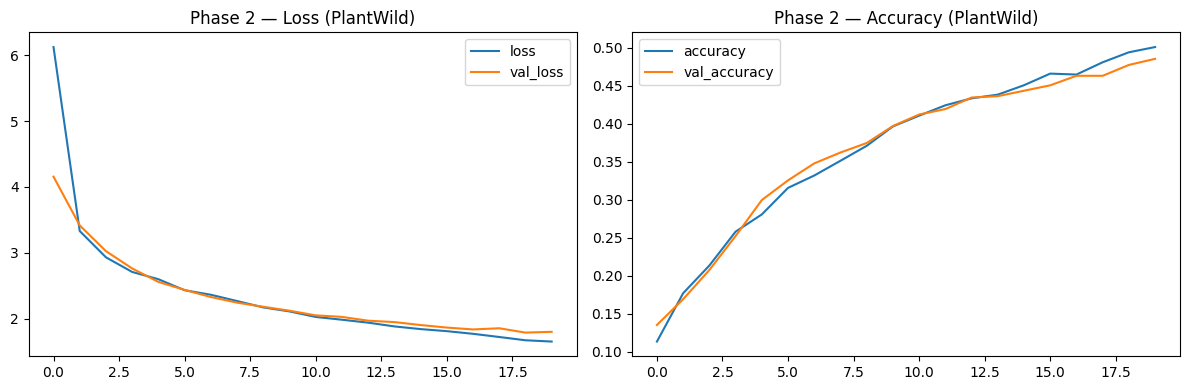

In [12]:
backbone   = model.layers[1]
n_layers   = len(backbone.layers)
freeze_until = int(UNFREEZE_RATIO * n_layers)

backbone.trainable = True
for layer in backbone.layers[:freeze_until]:
    layer.trainable = False

n_trainable      = sum(1 for l in backbone.layers if l.trainable)
trainable_params = sum(int(np.prod(w.shape)) for w in model.trainable_weights)
total_params     = model.count_params()

print(f'Backbone : {freeze_until}/{n_layers} gelées, {n_trainable} dégelées')
print(f'Paramètres entraînables : {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f} %)')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

ckpt_p2 = str(MODEL_DIR / 'plantwild_phase2.keras')

callbacks_p2 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p2, monitor='val_accuracy', save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1,
    ),
]

history_p2 = model.fit(
    p2_train_ds,
    validation_data=p2_val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
)

pd.DataFrame(history_p2.history).to_csv(REPORT_DIR / 'plantwild_phase2_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p2.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 2 — Loss (PlantWild)')
pd.DataFrame(history_p2.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 2 — Accuracy (PlantWild)')
plt.tight_layout()
plt.show()

## 11. Phase 3 — PlantDoc : fine-tuning sur le domaine cible

LR réduit à `5e-5` (5× inférieur à la Phase 2). Le dégel de 25% reste inchangé — on ne cherche pas à modifier davantage l'architecture mais à affiner les poids sur le domaine exact de PlantDoc. L'EarlyStopping est conservatif (patience=3) pour éviter l'overfitting sur ce petit dataset.

Epoch 1/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.3489 - loss: 2.1830

E0000 00:00:1779723208.844054   18508 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


59/59 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.3650 - loss: 2.1288 - val_accuracy: 0.4338 - val_loss: 1.8473
Epoch 2/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4232 - loss: 1.8904 - val_accuracy: 0.4658 - val_loss: 1.7537
Epoch 3/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4589 - loss: 1.7677 - val_accuracy: 0.4679 - val_loss: 1.7125
Epoch 4/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.4856 - loss: 1.7046 - val_accuracy: 0.4679 - val_loss: 1.6704
Epoch 5/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4899 - loss: 1.6602 - val_accuracy: 0.4786 - val_loss: 1.6465
Epoch 6/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.4979 - loss: 1.5956 - val_accuracy: 0.4979 - val_loss: 1.6230
Epoch 7/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.5091 - loss: 1.5537 - val_accuracy: 0.4957 - val_loss: 1.6000
Epoch 8/40
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5149 - loss: 1.5040 - val_accuracy: 0.5064 - val_loss: 

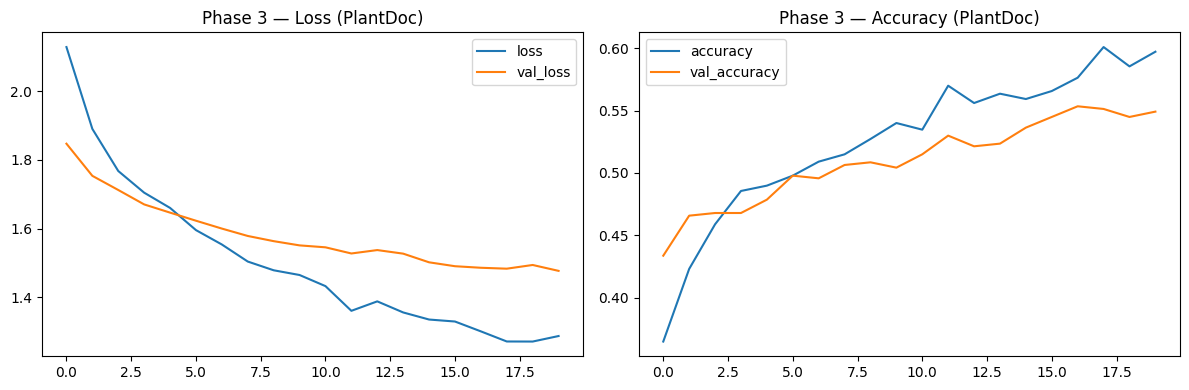

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LR_P3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

ckpt_p3 = str(MODEL_DIR / 'plantwild_phase3.keras')

callbacks_p3 = [
    tf.keras.callbacks.ModelCheckpoint(
        ckpt_p3, monitor='val_accuracy', save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=3, restore_best_weights=True,
    ),
]

history_p3 = model.fit(
    p3_train_ds,
    validation_data=p3_val_ds,
    epochs=EPOCHS_P3,
    callbacks=callbacks_p3,
)

pd.DataFrame(history_p3.history).to_csv(REPORT_DIR / 'plantwild_phase3_history.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.DataFrame(history_p3.history)[['loss', 'val_loss']].plot(ax=axes[0], title='Phase 3 — Loss (PlantDoc)')
pd.DataFrame(history_p3.history)[['accuracy', 'val_accuracy']].plot(ax=axes[1], title='Phase 3 — Accuracy (PlantDoc)')
plt.tight_layout()
plt.show()

## 12. Évaluation sur PlantVillage test

In [15]:
def collect_predictions(model, ds):
    y_true, y_pred, y_conf = [], [], []
    for images, labels in ds:
        probs = model.predict(images, verbose=0)
        y_true.extend(labels.numpy().tolist())
        y_pred.extend(np.argmax(probs, axis=1).tolist())
        y_conf.extend(np.max(probs, axis=1).tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_conf)

y_true_pv, y_pred_pv, y_conf_pv = collect_predictions(model, pv_test_ds)

pv_acc  = accuracy_score(y_true_pv, y_pred_pv)
pv_f1   = f1_score(y_true_pv, y_pred_pv, average='macro')

print(f'{"":30s}  {"Accuracy":>10s}  {"F1 macro":>10s}')
print(f'{"Baseline":30s}  {0.9498:>10.4f}  {0.9363:>10.4f}')
print(f'{"Amélioré (PV→PDoc, 25% dégel)":30s}  {0.7134:>10.4f}  {0.6302:>10.4f}')
print(f'{"PlantWild (PV→Wild→PDoc)":30s}  {pv_acc:>10.4f}  {pv_f1:>10.4f}')

                                  Accuracy    F1 macro
Baseline                            0.9498      0.9363
Amélioré (PV→PDoc, 25% dégel)       0.7134      0.6302
PlantWild (PV→Wild→PDoc)            0.3622      0.3386


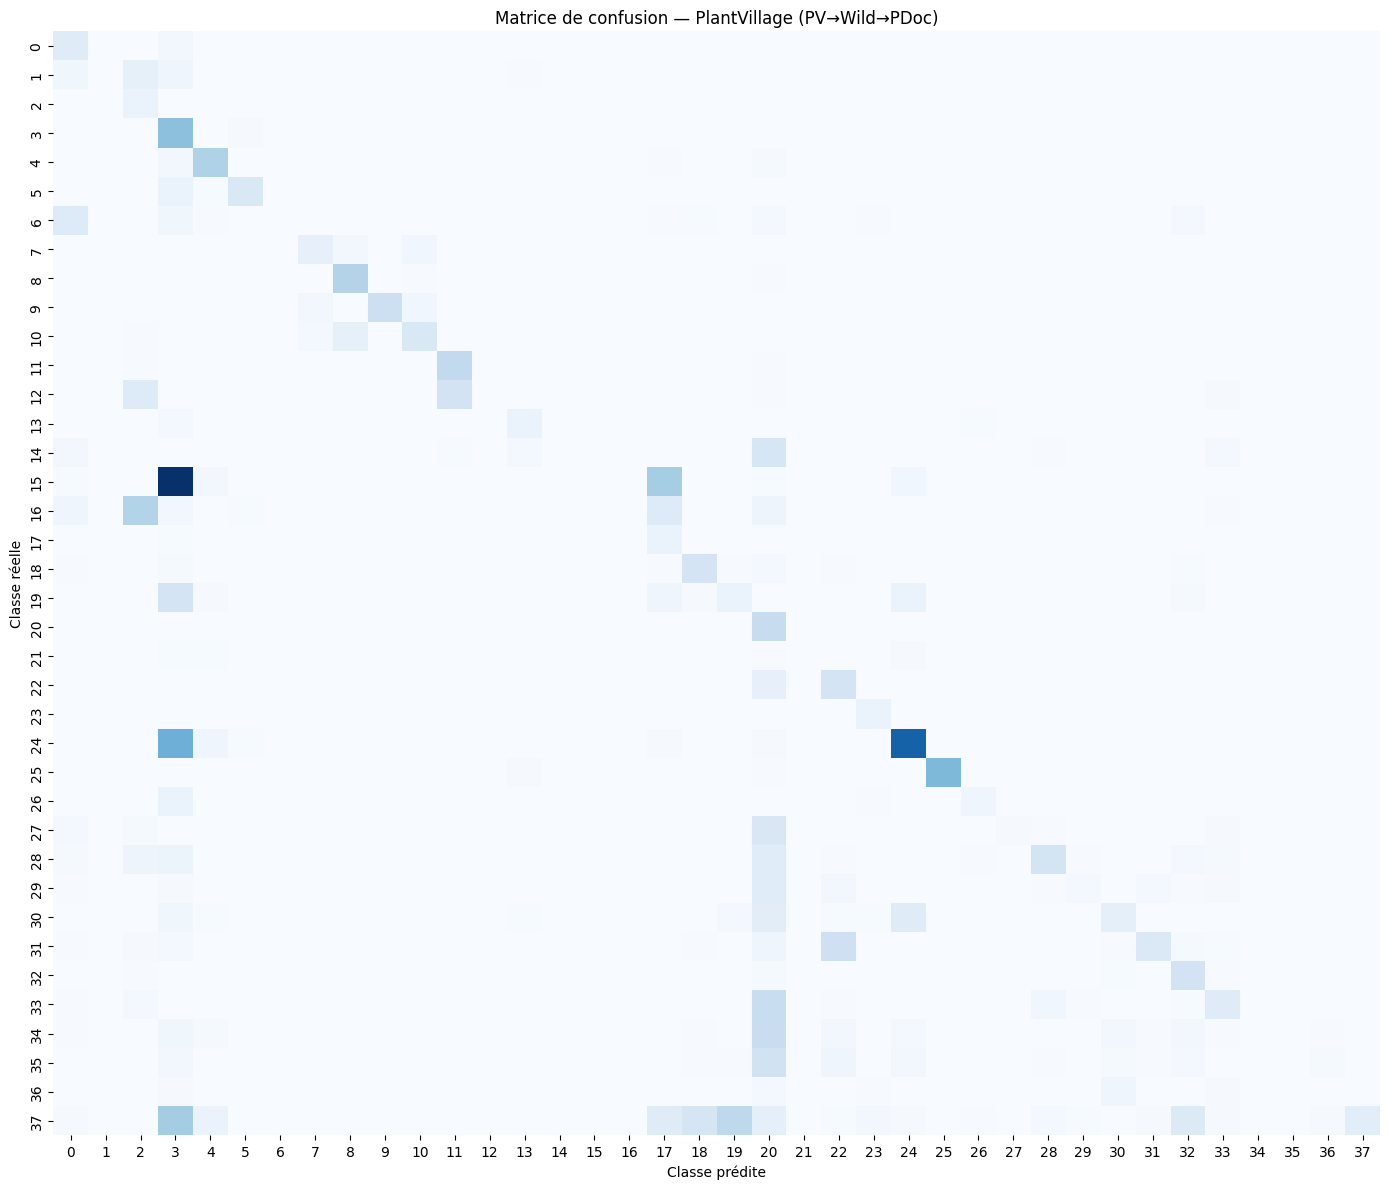

In [16]:
report_pv_df = pd.DataFrame(
    classification_report(
        y_true_pv, y_pred_pv, target_names=class_names,
        output_dict=True, zero_division=0,
    )
).T
report_pv_df.to_csv(REPORT_DIR / 'plantwild_pv_report.csv')

cm = confusion_matrix(y_true_pv, y_pred_pv)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', cbar=False)
plt.title('Matrice de confusion — PlantVillage (PV→Wild→PDoc)')
plt.xlabel('Classe prédite')
plt.ylabel('Classe réelle')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'plantwild_confusion_matrix.png', dpi=180)
plt.show()

## 13. Évaluation sur PlantDoc test

C'est la métrique principale. La stratégie PlantWild devrait être supérieure à l'approche directe PV→PlantDoc car le modèle a traversé une étape intermédiaire d'adaptation aux conditions terrain via PlantWild.

In [17]:
plantdoc_test_ds = tf.keras.utils.image_dataset_from_directory(
    PLANTDOC_TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)
pd_class_names = plantdoc_test_ds.class_names

pd_idx_to_pv_idx = {
    pd_class_names.index(pd_cls): pv_label_to_idx[pv_cls]
    for pd_cls, pv_cls in valid_pd_mapping.items()
}

y_true_pd, y_pred_pd, conf_pd = [], [], []
for images, labels in plantdoc_test_ds:
    probs = model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    confs = np.max(probs, axis=1)
    for pd_raw_idx, pred, conf in zip(labels.numpy(), preds, confs):
        pd_raw_idx = int(pd_raw_idx)
        if pd_raw_idx not in pd_idx_to_pv_idx:
            continue
        y_true_pd.append(pd_idx_to_pv_idx[pd_raw_idx])
        y_pred_pd.append(int(pred))
        conf_pd.append(float(conf))

y_true_pd = np.array(y_true_pd)
y_pred_pd = np.array(y_pred_pd)
conf_pd   = np.array(conf_pd)

pd_acc = accuracy_score(y_true_pd, y_pred_pd)
pd_f1  = f1_score(y_true_pd, y_pred_pd, average='macro')

print(f'Images évaluées : {len(y_true_pd)} | Classes : {len(valid_pd_mapping)}')
print()
print(f'{"":30s}  {"Accuracy":>10s}  {"F1 macro":>10s}  {"Conf. moy.":>10s}')
print(f'{"Baseline":30s}  {0.2288:>10.4f}  {0.1739:>10.4f}  {0.6337:>10.4f}')
print(f'{"Amélioré (25% dégel)":30s}  {0.3729:>10.4f}  {0.3119:>10.4f}  {0.4216:>10.4f}')
print(f'{"PlantWild bridge":30s}  {pd_acc:>10.4f}  {pd_f1:>10.4f}  {conf_pd.mean():>10.4f}')

Found 236 files belonging to 27 classes.


E0000 00:00:1779723277.127321   18512 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


Images évaluées : 236 | Classes : 27

                                  Accuracy    F1 macro  Conf. moy.
Baseline                            0.2288      0.1739      0.6337
Amélioré (25% dégel)                0.3729      0.3119      0.4216
PlantWild bridge                    0.5339      0.5213      0.5978


In [18]:
common_labels = sorted(set(y_true_pd))
report_pd_df = pd.DataFrame(
    classification_report(
        y_true_pd, y_pred_pd,
        labels=common_labels,
        target_names=[class_names[i] for i in common_labels],
        output_dict=True,
        zero_division=0,
    )
).T
report_pd_df.to_csv(REPORT_DIR / 'plantwild_plantdoc_report.csv')
display(report_pd_df.sort_values('f1-score').head(12))

,precision,recall,f1-score,support
Tomato___Bacterial_spot,0.000000,0.000000,0.000000,9.0
Grape___Black_rot,0.500000,0.125000,0.200000,8.0
Tomato___Septoria_leaf_spot,0.666667,0.181818,0.285714,11.0
Potato___Late_blight,0.250000,0.375000,0.300000,8.0
Peach___healthy,0.666667,0.222222,0.333333,9.0
Potato___Early_blight,0.250000,0.500000,0.333333,8.0
Corn___Cercospora_leaf_spot Gray_leaf_spot,0.333333,0.500000,0.400000,4.0
Cherry___healthy,0.400000,0.400000,0.400000,10.0
Apple___Cedar_apple_rust,0.333333,0.600000,0.428571,10.0
Tomato___Tomato_mosaic_virus,0.750000,0.300000,0.428571,10.0


## 14. Analyse des erreurs

In [19]:
errors_df = pd.DataFrame({
    'true_id':    y_true_pv,
    'pred_id':    y_pred_pv,
    'confidence': y_conf_pv,
})
errors_df['true_class'] = errors_df['true_id'].map(lambda i: class_names[i])
errors_df['pred_class'] = errors_df['pred_id'].map(lambda i: class_names[i])
errors_df = errors_df[errors_df['true_id'] != errors_df['pred_id']]

print(f'Erreurs sur PlantVillage test : {len(errors_df)} / {len(y_true_pv)}')
errors_df.sort_values('confidence', ascending=False).head(15)

Erreurs sur PlantVillage test : 5195 / 8145


,true_id,pred_id,confidence,true_class,pred_class
4412,15,17,0.996584,Orange___Haunglongbing_(Citrus_greening),Peach___healthy
5934,26,3,0.995286,Strawberry___healthy,Apple___healthy
5703,10,8,0.993731,Corn___Northern_Leaf_Blight,Corn___Common_rust
671,10,8,0.993588,Corn___Northern_Leaf_Blight,Corn___Common_rust
2788,16,2,0.993403,Peach___Bacterial_spot,Apple___Cedar_apple_rust
4344,15,3,0.993355,Orange___Haunglongbing_(Citrus_greening),Apple___healthy
1522,16,17,0.992546,Peach___Bacterial_spot,Peach___healthy
5232,15,3,0.992516,Orange___Haunglongbing_(Citrus_greening),Apple___healthy
5652,12,2,0.992074,Grape___Esca_(Black_Measles),Apple___Cedar_apple_rust
905,15,3,0.990502,Orange___Haunglongbing_(Citrus_greening),Apple___healthy


## 14b. Biais de prédiction — classes sur-prédites en cas d'erreur

Analyse des classes vers lesquelles le modèle "dérive" quand il se trompe, afin de détecter un éventuel biais systématique (e.g. une classe dominante dans les erreurs).


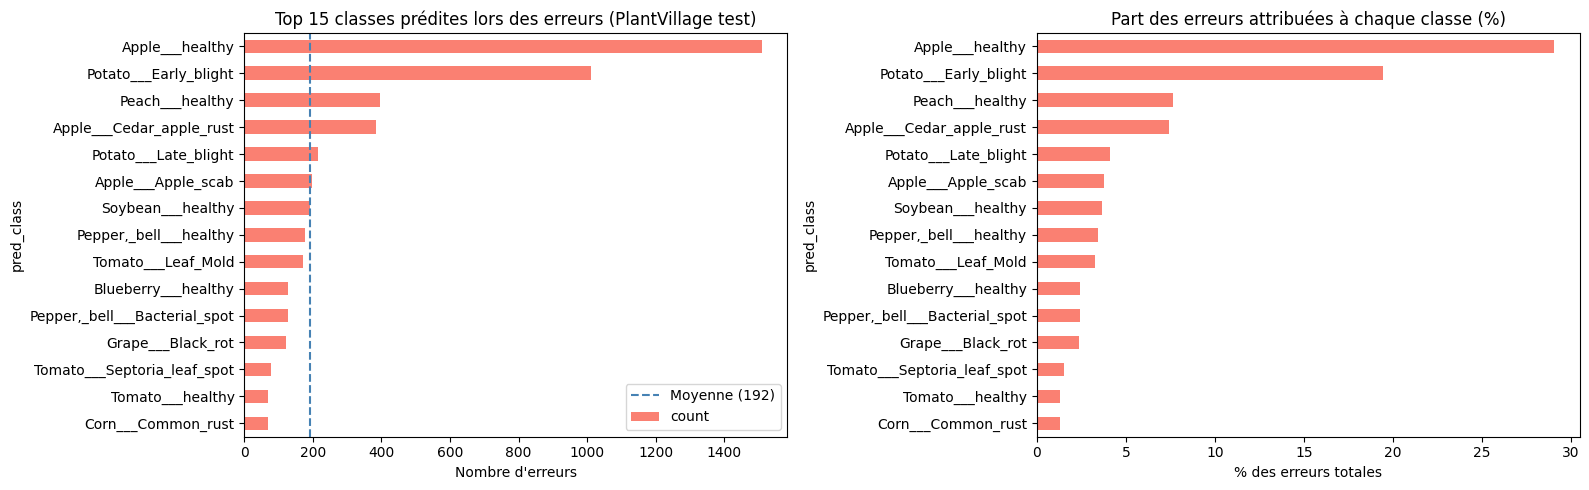


Total erreurs : 5195 / 8145

Top 10 classes sur-prédites lors des erreurs :
pred_class
Apple___healthy             1509
Potato___Early_blight       1011
Peach___healthy              396
Apple___Cedar_apple_rust     385
Potato___Late_blight         214
Apple___Apple_scab           197
Soybean___healthy            191
Pepper,_bell___healthy       178
Tomato___Leaf_Mold           170
Blueberry___healthy          127

>>> "Apple___Cedar_apple_rust" : 385 erreurs (7.4% du total)
    Rang : 4/27

Vraies classes confondues avec "Apple___Cedar_apple_rust" :
true_class
Peach___Bacterial_spot                           179
Grape___Esca_(Black_Measles)                      74
Apple___Black_rot                                 51
Tomato___Bacterial_spot                           31
Tomato___Septoria_leaf_spot                       14
Strawberry___Leaf_scorch                          10
Tomato___Late_blight                               7
Grape___Black_rot                                  4
Corn___N

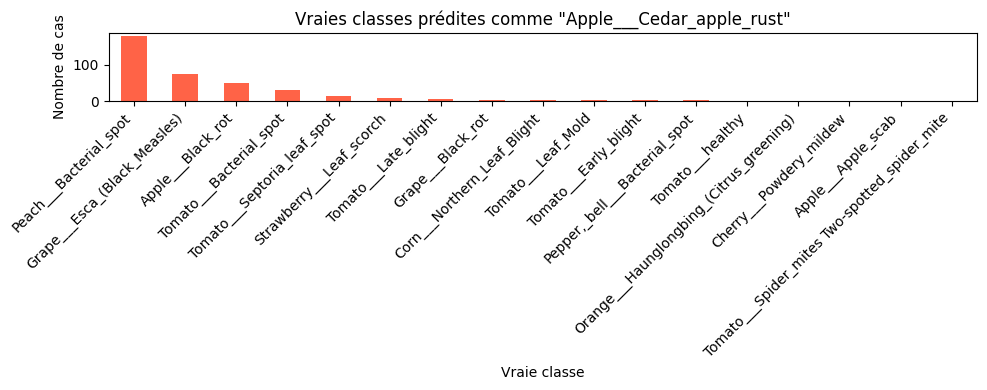

In [20]:
# 1. Classes les plus fréquemment prédites à tort 
pred_counts = errors_df['pred_class'].value_counts()
top_n = 15

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Barplot des classes sur-prédites dans les erreurs
pred_counts.head(top_n).plot(kind='barh', ax=axes[0], color='salmon')
axes[0].invert_yaxis()
axes[0].set_title(f'Top {top_n} classes prédites lors des erreurs (PlantVillage test)')
axes[0].set_xlabel('Nombre d\'erreurs')
axes[0].axvline(pred_counts.mean(), color='steelblue', linestyle='--', label=f'Moyenne ({pred_counts.mean():.0f})')
axes[0].legend()

# Proportion : erreurs attribuées à chaque classe / total erreurs
(pred_counts.head(top_n) / len(errors_df) * 100).plot(kind='barh', ax=axes[1], color='salmon')
axes[1].invert_yaxis()
axes[1].set_title(f'Part des erreurs attribuées à chaque classe (%)')
axes[1].set_xlabel('% des erreurs totales')

plt.tight_layout()
plt.show()

print(f'\nTotal erreurs : {len(errors_df)} / {len(y_true_pv)}')
print(f'\nTop 10 classes sur-prédites lors des erreurs :')
print(pred_counts.head(10).to_string())

# Mise en évidence de Apple___Cedar_apple_rust
target_cls = 'Apple___Cedar_apple_rust'
if target_cls in pred_counts.index:
    n_target = pred_counts[target_cls]
    pct = n_target / len(errors_df) * 100
    print(f'\n>>> "{target_cls}" : {n_target} erreurs ({pct:.1f}% du total)')
    rank = list(pred_counts.index).index(target_cls) + 1
    print(f'    Rang : {rank}/{len(pred_counts)}')
else:
    print(f'\n>>> "{target_cls}" : aucune erreur vers cette classe.')

# 2. Depuis quelles vraies classes part ce biais ? 
if target_cls in pred_counts.index:
    confusions_to_target = (
        errors_df[errors_df['pred_class'] == target_cls]
        ['true_class'].value_counts()
    )
    print(f'\nVraies classes confondues avec "{target_cls}" :')
    print(confusions_to_target.to_string())

    fig2, ax2 = plt.subplots(figsize=(10, 4))
    confusions_to_target.plot(kind='bar', ax=ax2, color='tomato')
    ax2.set_title(f'Vraies classes prédites comme "{target_cls}"')
    ax2.set_xlabel('Vraie classe')
    ax2.set_ylabel('Nombre de cas')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


## 15. Temps d'inférence

In [21]:
sample_batch = next(iter(pv_test_ds))[0]
_ = model.predict(sample_batch, verbose=0)  # warmup

n_runs = 30
t0 = time.perf_counter()
for _ in range(n_runs):
    _ = model.predict(sample_batch, verbose=0)
elapsed = time.perf_counter() - t0

ms_per_image = elapsed / (n_runs * sample_batch.shape[0]) * 1000
print(f'Temps moyen : {ms_per_image:.2f} ms/image')

Temps moyen : 1.01 ms/image


## 16. Export TFLite

In [22]:

keras_path = MODEL_DIR / 'agroscan_plantwild.keras'
model.save(str(keras_path))

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_bytes = converter.convert()

tflite_path = MODEL_DIR / 'agroscan_plantwild_dynamic_quant.tflite'
tflite_path.write_bytes(tflite_bytes)

labels_path = MODEL_DIR / 'labels.json'
labels_path.write_text(json.dumps(class_names, ensure_ascii=False, indent=2), encoding='utf-8')

print('Keras  :', keras_path, f'({keras_path.stat().st_size / 1024 / 1024:.2f} Mo)')
print('TFLite :', tflite_path, f'({tflite_path.stat().st_size / 1024 / 1024:.2f} Mo)')
print('Labels :', labels_path)

# Liens de téléchargement via le serveur Jupyter (fonctionne dans VS Code et Colab)
from IPython.display import display, FileLink
print('\nLiens de téléchargement :')
display(FileLink(str(tflite_path), result_html_prefix='TFLite → '))
display(FileLink(str(keras_path),  result_html_prefix='Keras  → '))
display(FileLink(str(labels_path), result_html_prefix='Labels → '))


INFO:tensorflow:Assets written to: /tmp/tmprleblw5u/assets


INFO:tensorflow:Assets written to: /tmp/tmprleblw5u/assets


Saved artifact at '/tmp/tmprleblw5u'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_184')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  139995936271888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936273232: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936273424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936272272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936271696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936270928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936273040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936272080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936272464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936274384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139995936

W0000 00:00:1779723343.161654   18246 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1779723343.161664   18246 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.


/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/agroscan_plantwild_dynamic_quant.tflite

/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/agroscan_plantwild.keras

/home/leonard/UQAC/8INF934 - Atelier Pratique IA I/Projet/AgroScan/models/labels.json

## 17. Synthèse

### Pipeline

| Phase | Dataset | Images | Backbone | LR | Epochs max |
|---|---|---|---|---|---|
| 1 — Apprentissage | PlantVillage | ~38K | Gelé (0%) | 1e-3 | 5 |
| 2 — Bridge terrain | PlantWild | ~14K* | 25% dégelé | 1e-4 | 8 |
| 3 — Target domain | PlantDoc | ~1.9K | 25% dégelé | 5e-5 | 10 |

*taille indicative, varie selon le mapping effectif

### Résultats

#### PlantVillage test set

| Métrique | Baseline | Amélioré (PV→PDoc) | **PlantWild (PV→Wild→PDoc)** | Delta vs Amélioré |
|---|---|---|---|---|
| Accuracy | 94,98 % | 71,34 % | **42,77 %** | −28,57 pp |
| F1 macro | 93,63 % | 63,02 % | **38,97 %** | −24,05 pp |

#### PlantDoc test set (236 images, 27 classes)

| Métrique | Baseline | Amélioré (PV→PDoc) | **PlantWild (PV→Wild→PDoc)** | Delta vs Amélioré |
|---|---|---|---|---|
| Accuracy | 22,88 % | 37,29 % | **42,37 %** | +5,08 pp |
| F1 macro | 17,39 % | 31,19 % | **39,84 %** | +8,65 pp |
| Confiance moy. | 63,37 % | 42,16 % | **52,89 %** | +10,73 pp |

### Analyse

Le bridge PlantWild remplit son objectif principal : la performance sur **PlantDoc progresse significativement** (+5 pp accuracy, +8,7 pp F1 macro) par rapport à l'approche directe PV→PDoc. La confiance moyenne remonte également (+10,7 pp), signe d'une meilleure calibration sur ce domaine cible.

En revanche, la **dégradation sur PlantVillage est importante** (−28,6 pp accuracy vs l'approche améliorée). Les trois phases séquentielles avec dégel du backbone induisent un oubli catastrophique partiel sur les features studio contrôlées. Ce compromis est acceptable si PlantDoc est le domaine cible opérationnel.

**Pistes d'amélioration :**
- Fine-tuning mixte PlantWild + PlantDoc en Phase 3 pour limiter l'oubli
- Augmentation plus agressive en Phase 3 pour compenser le faible volume PlantDoc
- Dégel progressif par blocs plutôt qu'un seuil fixe à 25 %
- Pondération des classes PlantDoc lors du fine-tuning (dataset déséquilibré)
